# Single Crop Inspector (from crop file only)
**Usage:**
- Set `VIDEO_PATH` to your original video.
- Set `CROP_FILE` to the crop you want to inspect (filename must contain `frame_XXXXX` and `_lYY`).
- Optional: set `META_DB` to a metadata JSON that includes bbox/conf for the crop.
- Run all cells. The notebook uses the saved crop directly (no re-detect) and draws the box if metadata is found.

In [15]:
# ========== EDIT THESE ==========
VIDEO_PATH = "../assets/store_cam3.mp4"     # path to the original video
CROP_FILE  = "outputs/test3/samples/frame_000190_t7.917_l5.jpg"
META_DB    = ""  # optional path to metadata JSON (e.g. .folder_db.json or crop_metadata.json)
# ==================================

In [16]:
import sys, os, re, json
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Option A: point directly to the reid_system folder
project_root = Path.cwd() / "reid_system"
if not (project_root / "config.py").exists():
    # If you ran the notebook from reid_system/experiments
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

from modules.reid_embedder import ReIDEmbedder

def resolve_metadata_db(meta_db: str, crop_path: Path, project_root: Path):
    if meta_db:
        candidates = [Path(meta_db), project_root / meta_db, Path.cwd() / meta_db]
        for c in candidates:
            if c.exists():
                return c
        raise FileNotFoundError(f"Metadata DB not found: {meta_db}")
    for p in [crop_path.parent] + list(crop_path.parents):
        candidate = p / ".folder_db.json"
        if candidate.exists():
            return candidate
        if p == project_root:
            break
    return None

def load_crop_metadata(db_path: Path, crop_path: Path, frame_idx: int, local_id: int):
    data = json.loads(db_path.read_text(encoding="utf-8"))
    if isinstance(data, dict) and "images" in data:
        for entry in data.get("images", []):
            if entry.get("file") == crop_path.name:
                return entry
    if isinstance(data, list):
        for entry in data:
            if entry.get("crop_filename") == crop_path.name:
                return entry
        for entry in data:
            if entry.get("frame_number") == frame_idx and entry.get("track_id") == local_id:
                return entry
    return None

# Load models
embedder = ReIDEmbedder(model_path=config.OSNET_MODEL)

video_path = Path(VIDEO_PATH)
if not video_path.is_absolute():
    # Allow paths relative to project_root when running from reid_system/experiments
    candidate = project_root / video_path
    if candidate.exists():
        video_path = candidate
if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path}")

crop_path = Path(CROP_FILE)
if not crop_path.is_absolute():
    # Allow paths relative to project_root when running from reid_system/experiments
    candidate = project_root / crop_path
    if candidate.exists():
        crop_path = candidate
if not crop_path.exists():
    raise FileNotFoundError(f"Crop not found: {crop_path}")

pattern = re.compile(r"frame_(\d+).*_l(\d+)")
match = pattern.search(crop_path.stem)
if not match:
    raise ValueError("Crop filename must contain 'frame_XXXX' and '_lYY'.")

frame_idx = int(match.group(1))   # 1-based (assuming filenames start at 1)
local_id_target = int(match.group(2))

meta_db_path = resolve_metadata_db(META_DB, crop_path, project_root)
crop_meta = None
if meta_db_path:
    crop_meta = load_crop_metadata(meta_db_path, crop_path, frame_idx, local_id_target)
    if crop_meta is None:
        print(f"Metadata DB found but crop not indexed: {meta_db_path}")

meta_bbox = None
meta_conf = None
meta_frame = None
meta_local_id = None
if crop_meta:
    if "bbox" in crop_meta and crop_meta["bbox"] is not None:
        meta_bbox = tuple(int(v) for v in crop_meta["bbox"])
    for key in ("confidence", "conf", "score", "det_conf"):
        if key in crop_meta and crop_meta[key] is not None:
            meta_conf = crop_meta[key]
            break
    if meta_conf is not None:
        try:
            meta_conf = float(meta_conf)
        except (TypeError, ValueError):
            pass
    meta_frame = crop_meta.get("frame", crop_meta.get("frame_number"))
    meta_local_id = crop_meta.get("local_id", crop_meta.get("track_id"))


ReID embedder loaded (ONNX, CPU). Input size: 128x256


In [17]:
# Open video and seek to the target frame
cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise IOError(f"Cannot open video: {video_path}")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Seek to frame_idx (0-based index in OpenCV)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx - 1)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"Could not read frame {frame_idx} from video.")

print(f"Frame {frame_idx}/{total_frames} loaded (fps={fps:.2f}, {width}x{height})")

Frame 190/379 loaded (fps=24.00, 3840x2160)


In [18]:
# Load provided crop and metadata (no re-detect)
provided_crop = cv2.imread(str(crop_path))
if provided_crop is None:
    raise RuntimeError("Failed to load provided crop image.")

detections = []

target_det = {
    "local_id": local_id_target,
    "bbox": meta_bbox,
    "conf": meta_conf,
    "crop": provided_crop,
}

if meta_db_path:
    print(f"Metadata DB: {meta_db_path}")
else:
    print("Metadata DB: not found (set META_DB to enable bbox/conf).")

if meta_frame is not None:
    print(f"Metadata frame: {meta_frame}")
if meta_local_id is not None:
    print(f"Metadata local_id: {meta_local_id}")
if meta_conf is not None:
    print(f"Confidence: {meta_conf:.3f}")
else:
    print("Confidence: n/a")
if meta_bbox is not None:
    print(f"BBox: {meta_bbox}")


Metadata DB: not found (set META_DB to enable bbox/conf).
Confidence: n/a


In [19]:
# Compute metrics on the YOLO crop
bbox = target_det['bbox']
crop_yolo = target_det['crop']
h, w = crop_yolo.shape[:2]
gray = cv2.cvtColor(crop_yolo, cv2.COLOR_BGR2GRAY)
sharpness = cv2.Laplacian(gray, cv2.CV_32F).var()
area_ratio = (w * h) / (width * height)
aspect = max(w, h) / max(1, min(w, h))

# ReID embedding
emb = embedder.extract_embedding(crop_yolo)
emb_norm = np.linalg.norm(emb)

# Quality gates (same as pipeline)
filters = {
    'Save width':        (w >= config.MIN_WIDTH,           f'>={config.MIN_WIDTH}'),
    'Save height':       (h >= config.MIN_HEIGHT,          f'>={config.MIN_HEIGHT}'),
    'Save area ratio':   (area_ratio >= config.MIN_AREA_RATIO, f'>={config.MIN_AREA_RATIO:.4f}'),
    'Save sharpness':    (sharpness >= config.MIN_SHARPNESS,  f'>={config.MIN_SHARPNESS}'),
    'ReID width':        (w >= config.MIN_REID_WIDTH,      f'>={config.MIN_REID_WIDTH}'),
    'ReID height':       (h >= config.MIN_REID_HEIGHT,     f'>={config.MIN_REID_HEIGHT}'),
    'ReID area ratio':   (area_ratio >= config.MIN_REID_AREA_RATIO, f'>={config.MIN_REID_AREA_RATIO:.4f}'),
    'ReID sharpness':    (sharpness >= config.MIN_REID_SHARPNESS,  f'>={config.MIN_REID_SHARPNESS}'),
    'Refine area ratio': (area_ratio >= config.REFINE_MIN_REID_AREA_RATIO, f'>={config.REFINE_MIN_REID_AREA_RATIO:.4f}'),
    'Refine sharpness':  (sharpness >= config.REFINE_MIN_REID_SHARPNESS,  f'>={config.REFINE_MIN_REID_SHARPNESS}'),
    'Refine aspect':     (aspect <= config.REFINE_MAX_ASPECT_RATIO if config.REFINE_MAX_ASPECT_RATIO else True,
                          f'<={config.REFINE_MAX_ASPECT_RATIO}' if config.REFINE_MAX_ASPECT_RATIO else 'disabled'),
}

# Print filter table
print(f"\n{'Filter':<20s} {'Value':<12s} {'Threshold':<15s} {'Pass'}")
print("-"*60)
for name, (passed, thresh_str) in filters.items():
    if 'width' in name:
        val_str = f"{w}"
    elif 'height' in name:
        val_str = f"{h}"
    elif 'aspect' in name:
        val_str = f"{aspect:.2f}"
    elif 'sharpness' in name:
        val_str = f"{sharpness:.1f}"
    elif 'area' in name:
        val_str = f"{area_ratio:.5f}"
    else:
        val_str = ""
    print(f"{name:<20s} {val_str:<12s} {thresh_str:<15s} {'✅' if passed else '❌'}")

overall = all(p[0] for p in filters.values())
print(f"\nOverall: {'PASS' if overall else 'FAIL'}")


Filter               Value        Threshold       Pass
------------------------------------------------------------
Save width           71           >=10            ✅
Save height          126          >=20            ✅
Save area ratio      0.00108      >=0.0010        ✅
Save sharpness       419.8        >=8.0           ✅
ReID width           71           >=10            ✅
ReID height          126          >=20            ✅
ReID area ratio      0.00108      >=0.0012        ❌
ReID sharpness       419.8        >=12.0          ✅
Refine area ratio    0.00108      >=0.0012        ❌
Refine sharpness     419.8        >=12.0          ✅
Refine aspect        1.77         <=4.0           ✅

Overall: FAIL


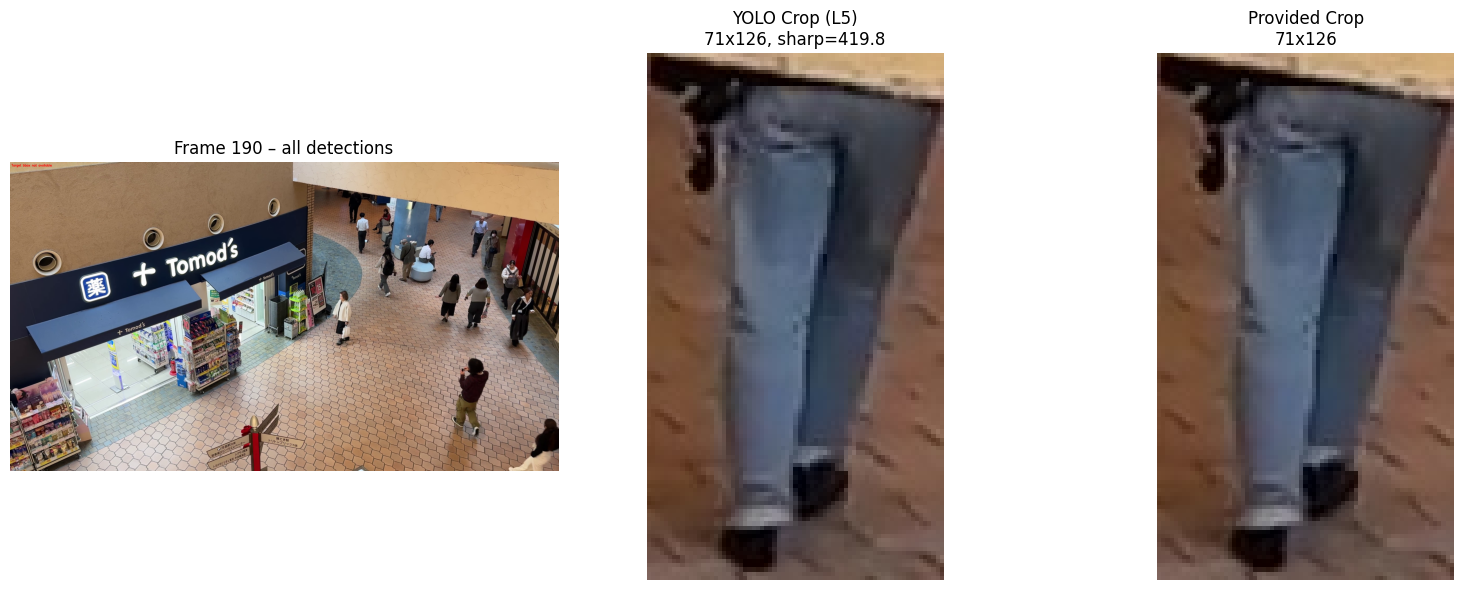

In [20]:
# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# 1. Original frame with all detections
ax = axes[0]
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
img_boxes = frame_rgb.copy()
for det in detections:
    x1, y1, x2, y2 = det['bbox']
    cv2.rectangle(img_boxes, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_boxes, f"L{det['local_id']}", (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
# Highlight target if bbox is available
if target_det['bbox'] is not None:
    x1, y1, x2, y2 = target_det['bbox']
    cv2.rectangle(img_boxes, (x1, y1), (x2, y2), (255, 0, 0), 3)
    cv2.putText(img_boxes, f"TARGET L{target_det['local_id']}", (x1, y2+15),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
else:
    cv2.putText(img_boxes, "Target bbox not available", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
ax.imshow(img_boxes)
ax.set_title(f"Frame {frame_idx} – all detections")
ax.axis('off')

# 2. YOLO crop
ax = axes[1]
ax.imshow(cv2.cvtColor(crop_yolo, cv2.COLOR_BGR2RGB))
ax.set_title(f"YOLO Crop (L{target_det['local_id']})\n{w}x{h}, sharp={sharpness:.1f}")
ax.axis('off')

# 3. Provided crop (the one you gave)
ax = axes[2]
ax.imshow(cv2.cvtColor(provided_crop, cv2.COLOR_BGR2RGB))
ax.set_title(f"Provided Crop\n{provided_crop.shape[1]}x{provided_crop.shape[0]}")
ax.axis('off')

plt.tight_layout()
plt.show()

In [21]:
# ReID embedding details (optional)
print(f"\nReID Embedding:")
print(f"  Shape: {emb.shape}")
print(f"  L2 norm: {emb_norm:.3f}")
print(f"  First 8 values: {emb[:8]}")


ReID Embedding:
  Shape: (512,)
  L2 norm: 1.000
  First 8 values: [0.05334734 0.10591669 0.         0.         0.0461829  0.04621043
 0.         0.08058693]


### How to interpret the output
- **Filter table** – any ❌ shows which threshold rejected the crop.
- If the YOLO crop and your provided crop differ significantly, the detection match may be wrong; check the target local ID.
- Adjust thresholds in `config.py` and re‑run this notebook to see the effect on the same crop.